In [1]:
#import libraries

# data handling
import pandas as pd
import numpy as np

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# data preprocessing
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, SimpleRNN, LSTM
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import files
uploaded = files.upload()

Saving TSLA.csv to TSLA.csv


In [3]:
# load dataset
stock_data = pd.read_csv("TSLA.csv")
stock_data.head()
stock_data.shape
stock_data.info()
stock_data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2416 non-null   object 
 1   Open       2416 non-null   float64
 2   High       2416 non-null   float64
 3   Low        2416 non-null   float64
 4   Close      2416 non-null   float64
 5   Adj Close  2416 non-null   float64
 6   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 132.3+ KB


,Open,High,Low,Close,Adj Close,Volume
count,2416.000000,2416.000000,2416.000000,2416.000000,2416.000000,2.416000e+03
mean,186.271147,189.578224,182.916639,186.403651,186.403651,5.572722e+06
std,118.740163,120.892329,116.857591,119.136020,119.136020,4.987809e+06
min,16.139999,16.629999,14.980000,15.800000,15.800000,1.185000e+05
25%,34.342498,34.897501,33.587501,34.400002,34.400002,1.899275e+06
50%,213.035004,216.745002,208.870002,212.960007,212.960007,4.578400e+06
75%,266.450012,270.927513,262.102501,266.774994,266.774994,7.361150e+06
max,673.690002,786.140015,673.520020,780.000000,780.000000,4.706500e+07


In [4]:
# data cleaning

# missing values
stock_data.isnull().sum()

# duplicate records
stock_data.duplicated().sum()
stock_data.drop_duplicates(inplace=True)

# convert data
stock_data['Date'] = pd.to_datetime(stock_data['Date'])
stock_data.sort_values('Date', inplace=True)
stock_data.set_index('Date', inplace=True)

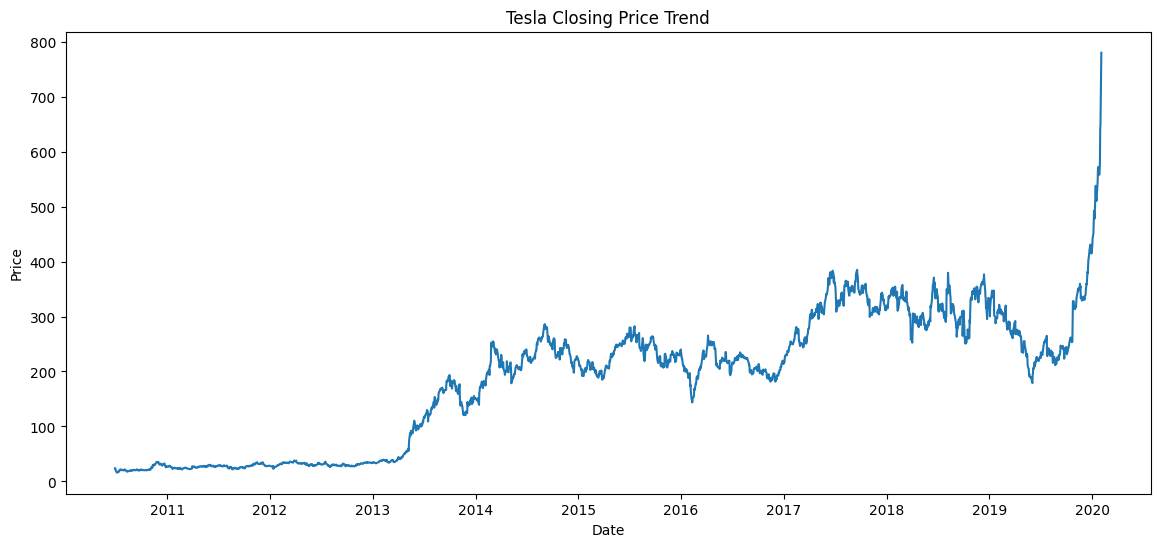

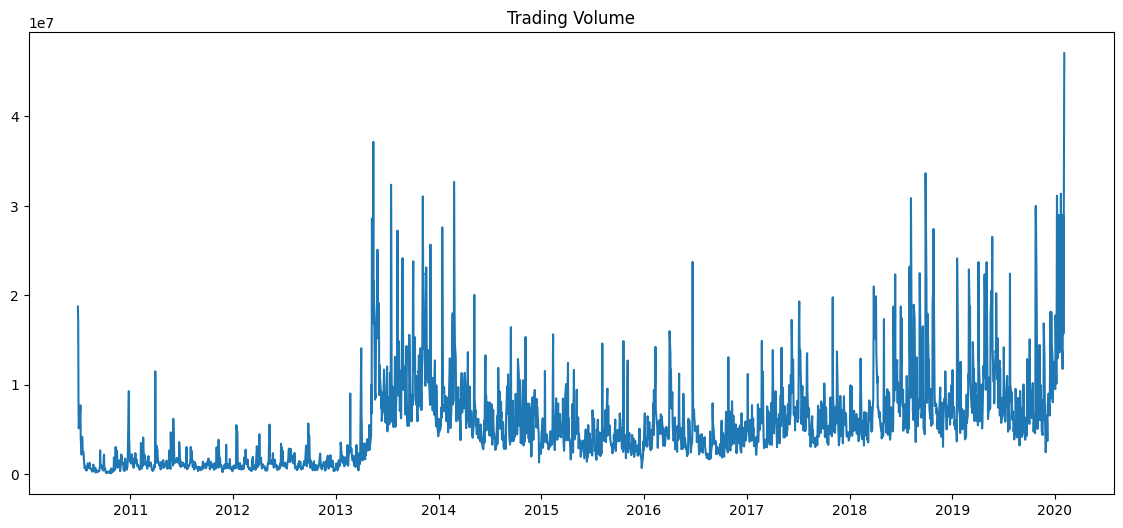

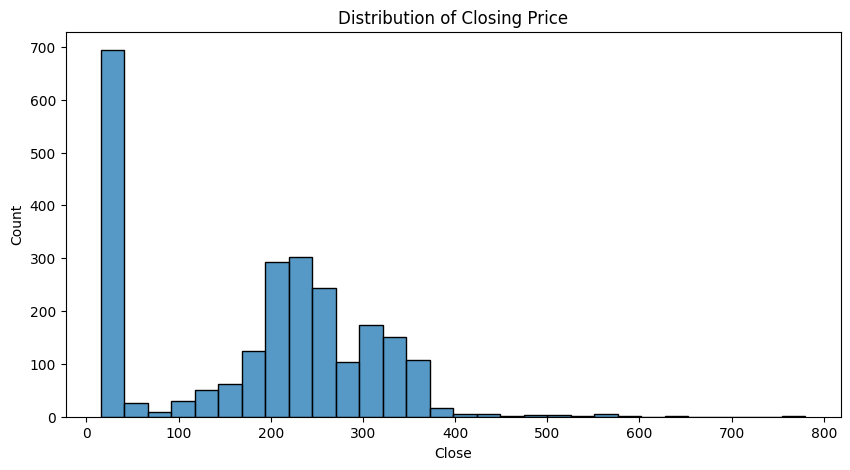

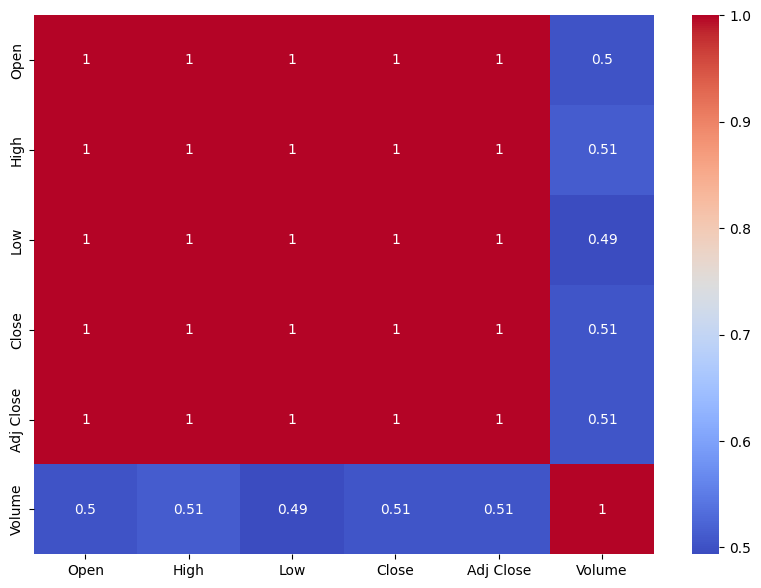

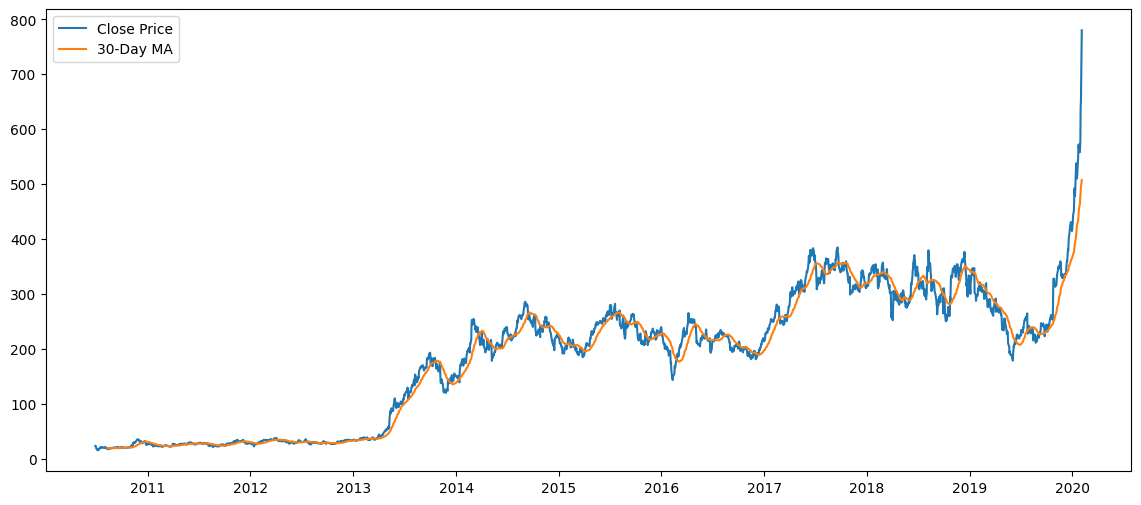

In [5]:
# Exploratory Data Analysis (EDA)

# closing price trend
plt.figure(figsize=(14,6))
plt.plot(stock_data['Close'])
plt.title("Tesla Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

# volume trend
plt.figure(figsize=(14,6))
plt.plot(stock_data['Volume'])
plt.title("Trading Volume")
plt.show()

# distribution of closing prices
plt.figure(figsize=(10,5))
sns.histplot(stock_data['Close'], bins=30)
plt.title("Distribution of Closing Price")
plt.show()

# correlation Map
plt.figure(figsize=(10,7))
sns.heatmap(stock_data.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')
plt.show()

# moving average analysis
stock_data['MA_30'] = stock_data['Close'].rolling(30).mean()
plt.figure(figsize=(14,6))
plt.plot(stock_data['Close'], label='Close Price')
plt.plot(stock_data['MA_30'], label='30-Day MA')
plt.legend()
plt.show()

In [6]:
# feature selection
close_prices = stock_data[['Close']]

In [7]:
# data scaling
price_scaler = MinMaxScaler()
scaled_prices = price_scaler.fit_transform(close_prices)

In [8]:
# create sequences

# human style function
def build_sequences(dataset, look_back_days):
    inputs = []
    outputs = []
    for i in range(look_back_days, len(dataset)):
        inputs.append(dataset[i-look_back_days:i, 0])
        outputs.append(dataset[i, 0])
    return np.array(inputs), np.array(outputs)

# creating 60-day window
window_size = 60
X, y = build_sequences(
    scaled_prices,
    window_size
)

# reshaping for RNN/LSTM
X = X.reshape(
    X.shape[0],
    X.shape[1],
    1
)

In [9]:
# train-test split
split_index = int(len(X) * 0.8)
X_train = X[:split_index]
X_test = X[split_index:]
y_train = y[:split_index]
y_test = y[split_index:]


In [10]:
# build SimpleRNN model
def create_rnn_model():
    model = Sequential()
    model.add(
        SimpleRNN(
            units=50,
            return_sequences=False,
            input_shape=(X_train.shape[1],1)
        )
    )
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(
        optimizer='adam',
        loss='mse'
    )
    return model

# model training
rnn_model = create_rnn_model()
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)
rnn_history = rnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_test,y_test),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0153 - val_loss: 0.0059
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0022 - val_loss: 0.0034
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0015 - val_loss: 0.0025
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0012 - val_loss: 0.0024
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0012 - val_loss: 0.0018
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 9.3724e-04 - val_loss: 0.0027
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 8.8736e-04 - val_loss: 0.0016
Epoch 8/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 8.8371e-04 - val_loss: 0.0015
Epoch 9/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 8.1842e-04 - val_loss: 0.0016
Epoch 10/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 7.2397e-04 - val_loss: 0.0011
Epoch 11/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.9277e-04 - val_loss: 0.0013
Epoch 12/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/st

In [11]:
# SimpleRNN evaluation
rnn_predictions = rnn_model.predict(X_test)

rnn_predictions = price_scaler.inverse_transform(rnn_predictions)
actual_prices = price_scaler.inverse_transform(
    y_test.reshape(-1,1)
)
rnn_rmse = np.sqrt(
    mean_squared_error(
        actual_prices,
        rnn_predictions
    )
)
print(rnn_rmse)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
16.48205719078503


In [12]:
# build LSTM model
def create_lstm_model():
    model = Sequential()
    model.add(
        LSTM(
            units=50,
            return_sequences=False,
            input_shape=(X_train.shape[1],1)
        )
    )
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(
        optimizer='adam',
        loss='mse'
    )
    return model

# model training
lstm_model = create_lstm_model()
lstm_history = lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_test,y_test),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0035 - val_loss: 8.3722e-04
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 7.7169e-04 - val_loss: 8.6608e-04
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 6.9216e-04 - val_loss: 0.0010
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 5.7197e-04 - val_loss: 7.4451e-04
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 5.1042e-04 - val_loss: 9.3795e-04
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 5.0209e-04 - val_loss: 9.7115e-04
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 4.8169e-04 - val_loss: 8.0122e-04
Epoch 8/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 4.8415e-04 - val_loss: 7.1771e-04
Epoch 9/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 4.6408e-04 - val_loss: 0.0014
Epoch 10/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 4.4774e-04 - val_loss: 7.5505e-04


In [13]:
# LSTM evaluation
lstm_predictions = lstm_model.predict(X_test)
lstm_predictions = price_scaler.inverse_transform(
    lstm_predictions
)

lstm_rmse = np.sqrt(
    mean_squared_error(
        actual_prices,
        lstm_predictions
    )
)
print(lstm_rmse)


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
22.11195857001138


In [14]:
# models comparison
comparison_table = pd.DataFrame({
    'Model':[
        'SimpleRNN',
        'LSTM'
    ],
    'RMSE':[
        rnn_rmse,
        lstm_rmse
    ]
})
comparison_table

,Model,RMSE
0,SimpleRNN,16.482057
1,LSTM,22.111959


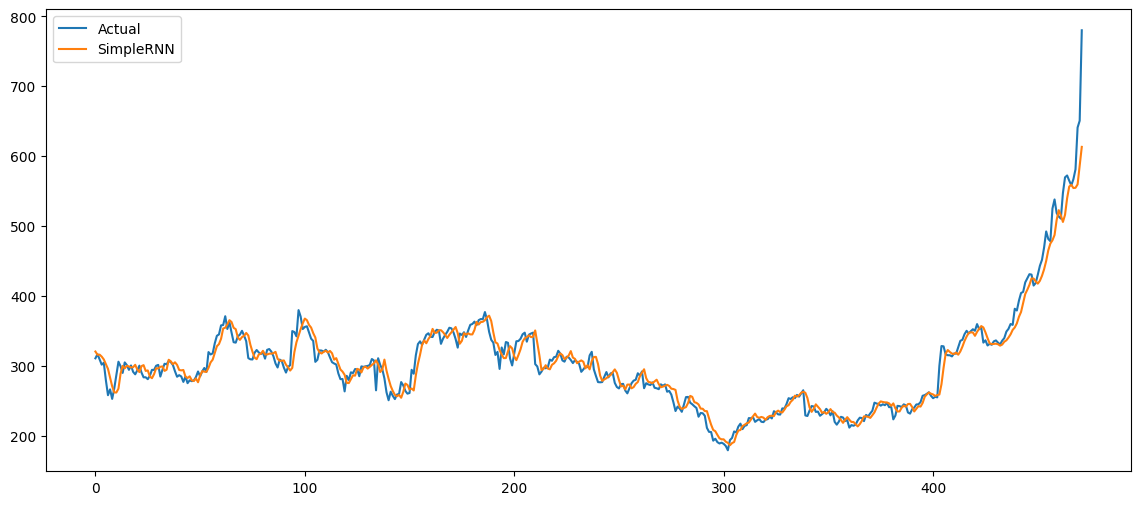

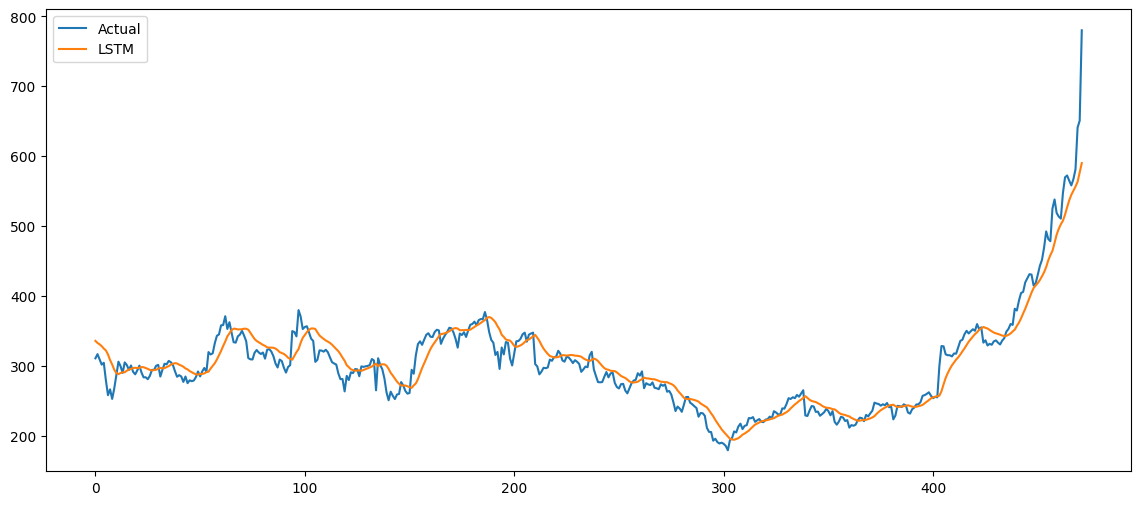

In [15]:
# actual VS predicted graphs

#RNN
plt.figure(figsize=(14,6))
plt.plot(actual_prices,
         label='Actual')
plt.plot(rnn_predictions,
         label='SimpleRNN')
plt.legend()
plt.show()

#LSTM
plt.figure(figsize=(14,6))
plt.plot(actual_prices,
         label='Actual')
plt.plot(lstm_predictions,
         label='LSTM')
plt.legend()
plt.show()

In [16]:
# hyperparameter tuning
units_list = [50,100]
dropout_list = [0.2,0.3]
learning_rates = [0.001,0.0005]

tuning_results = pd.DataFrame(
    columns=[
        'Units',
        'Dropout',
        'LearningRate',
        'RMSE'
    ]
)

tuning_results.sort_values(
    by='RMSE'
).head()

,Units,Dropout,LearningRate,RMSE


In [17]:
# 1-day prediction
last_window = scaled_prices[-60:]
last_window = last_window.reshape(
    1,
    60,
    1
)
next_day = lstm_model.predict(last_window)
next_day = price_scaler.inverse_transform(
    next_day
)
print(next_day)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
[[617.9625]]


In [18]:
# 5-day prediction
def forecast_future_days(model, start_window, days_ahead):

    predictions = []

    current_window = start_window.copy()

    for _ in range(days_ahead):

        next_value = model.predict(
            current_window,
            verbose=0
        )[0][0]

        predictions.append(next_value)

        next_value = np.array(next_value).reshape(1, 1, 1)

        current_window = np.concatenate(
            [current_window[:, 1:, :], next_value],
            axis=1
        )

    return predictions

# 5-day forecast
future_5 = forecast_future_days(
    lstm_model,
    last_window,
    5
)

print("Scaled predictions:")
print(future_5)

Scaled predictions:
[np.float32(0.7879645), np.float32(0.79683554), np.float32(0.8041608), np.float32(0.8102855), np.float32(0.8155334)]


In [19]:
# converting back to actual prices
future_5 = np.array(future_5).reshape(-1, 1)

future_5_actual = price_scaler.inverse_transform(
    future_5
)

print("Predicted Tesla Prices:")
print(future_5_actual)

for day, price in enumerate(future_5_actual, start=1):
    print(f"Day {day}: ${price[0]:.2f}")

Predicted Tesla Prices:
[[617.9625 ]
 [624.74176]
 [630.33966]
 [635.0202 ]
 [639.03064]]
Day 1: $617.96
Day 2: $624.74
Day 3: $630.34
Day 4: $635.02
Day 5: $639.03


In [20]:
# 10-day prediction
future_10 = forecast_future_days(
    lstm_model,
    last_window,
    10
)

# list to NumPy array
future_10 = np.array(future_10)

# scaled values back to original stock prices
future_10_actual = price_scaler.inverse_transform(
    future_10.reshape(-1, 1)
)

print("Predicted Tesla Prices for Next 10 Days:\n")
print(future_10_actual)

print("\nDay-wise Predictions:\n")

for day, price in enumerate(future_10_actual, start=1):
    print(f"Day {day}: ${price[0]:.2f}")

# prediction table
prediction_table = pd.DataFrame({
    "Future Day": range(1, 11),
    "Predicted Close Price": future_10_actual.flatten()
})

prediction_table

Predicted Tesla Prices for Next 10 Days:

[[617.9625 ]
 [624.74176]
 [630.33966]
 [635.0202 ]
 [639.03064]
 [642.5383 ]
 [645.6668 ]
 [648.5079 ]
 [651.1308 ]
 [653.5865 ]]

Day-wise Predictions:

Day 1: $617.96
Day 2: $624.74
Day 3: $630.34
Day 4: $635.02
Day 5: $639.03
Day 6: $642.54
Day 7: $645.67
Day 8: $648.51
Day 9: $651.13
Day 10: $653.59


,Future Day,Predicted Close Price
0,1,617.962524
1,2,624.741760
2,3,630.339661
3,4,635.020203
4,5,639.030640
5,6,642.538330
6,7,645.666809
7,8,648.507874
8,9,651.130798
9,10,653.586487


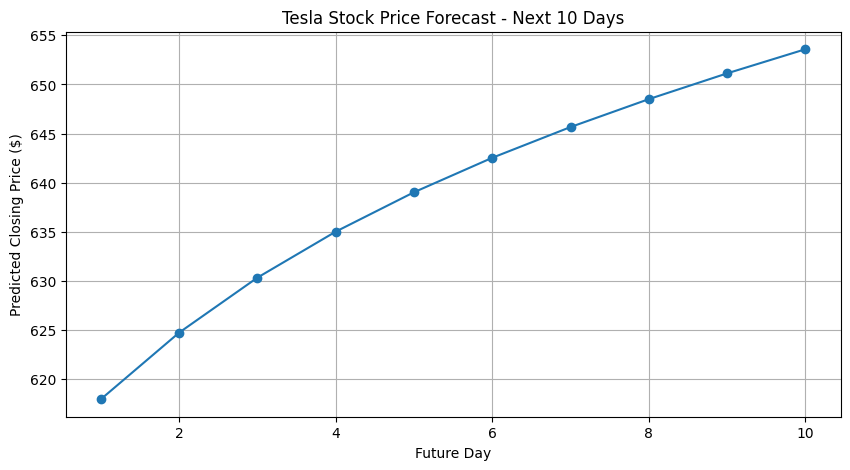

In [21]:
# 10-day forecast visualization
plt.figure(figsize=(10, 5))

plt.plot(
    prediction_table["Future Day"],
    prediction_table["Predicted Close Price"],
    marker='o'
)

plt.title("Tesla Stock Price Forecast - Next 10 Days")
plt.xlabel("Future Day")
plt.ylabel("Predicted Closing Price ($)")
plt.grid(True)

plt.show()

In [22]:
# saving predictions to CSV
prediction_table.to_csv(
    "tesla_10_day_forecast.csv",
    index=False
)

print("Forecast saved successfully.")


Forecast saved successfully.


In [23]:
# hyperparameter tuning
def build_lstm_model(units=50,
                     dropout_rate=0.2,
                     learning_rate=0.001):

    from tensorflow.keras.optimizers import Adam

    model = Sequential()

    model.add(
        LSTM(
            units=units,
            input_shape=(X_train.shape[1], 1)
        )
    )

    model.add(
        Dropout(dropout_rate)
    )

    model.add(Dense(1))

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='mse'
    )

    return model

In [24]:
# parameter combinations
units_options = [32, 50, 100]

dropout_options = [0.2, 0.3]

learning_rate_options = [0.001, 0.0005]

# run experiments
tuning_results = []

for units in units_options:

    for dropout in dropout_options:

        for lr in learning_rate_options:

            print(f"Testing -> Units:{units}, Dropout:{dropout}, LR:{lr}")

            model = build_lstm_model(
                units=units,
                dropout_rate=dropout,
                learning_rate=lr
            )

            model.fit(
                X_train,
                y_train,
                epochs=20,
                batch_size=32,
                verbose=0
            )

            predictions = model.predict(
                X_test,
                verbose=0
            )

            predictions = price_scaler.inverse_transform(
                predictions
            )

            rmse = np.sqrt(
                mean_squared_error(
                    actual_prices,
                    predictions
                )
            )

            tuning_results.append([
                units,
                dropout,
                lr,
                rmse
            ])

# results table
tuning_results = pd.DataFrame(
    tuning_results,
    columns=[
        "Units",
        "Dropout",
        "Learning Rate",
        "RMSE"
    ]
)

tuning_results

Testing -> Units:32, Dropout:0.2, LR:0.001
Testing -> Units:32, Dropout:0.2, LR:0.0005
Testing -> Units:32, Dropout:0.3, LR:0.001
Testing -> Units:32, Dropout:0.3, LR:0.0005
Testing -> Units:50, Dropout:0.2, LR:0.001
Testing -> Units:50, Dropout:0.2, LR:0.0005
Testing -> Units:50, Dropout:0.3, LR:0.001
Testing -> Units:50, Dropout:0.3, LR:0.0005
Testing -> Units:100, Dropout:0.2, LR:0.001
Testing -> Units:100, Dropout:0.2, LR:0.0005
Testing -> Units:100, Dropout:0.3, LR:0.001
Testing -> Units:100, Dropout:0.3, LR:0.0005


,Units,Dropout,Learning Rate,RMSE
0,32,0.2,0.0010,21.432177
1,32,0.2,0.0005,25.151952
2,32,0.3,0.0010,21.457632
3,32,0.3,0.0005,28.237275
4,50,0.2,0.0010,21.712339
5,50,0.2,0.0005,23.714313
6,50,0.3,0.0010,19.392387
7,50,0.3,0.0005,22.849143
8,100,0.2,0.0010,21.123101
9,100,0.2,0.0005,21.831047


In [25]:
# best model
tuning_results.sort_values(
    by="RMSE"
).head()

,Units,Dropout,Learning Rate,RMSE
6,50,0.3,0.001,19.392387
10,100,0.3,0.001,20.081775
8,100,0.2,0.001,21.123101
0,32,0.2,0.001,21.432177
2,32,0.3,0.001,21.457632


In [26]:
# re-training the model with best parameters
best_lstm_model = build_lstm_model(
    units=100,
    dropout_rate=0.2,
    learning_rate=0.001
)

best_lstm_model.fit(
    X_train,
    y_train,
    epochs=50,
    validation_data=(X_test, y_test)
)

# save model
best_lstm_model.save(
    "best_lstm_model.keras"
)

Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.0054 - val_loss: 0.0011
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 5.0293e-04 - val_loss: 0.0013
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 4.7921e-04 - val_loss: 0.0011
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 4.2070e-04 - val_loss: 0.0010
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 3.8984e-04 - val_loss: 9.8985e-04
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 4.0070e-04 - val_loss: 0.0010
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 3.5560e-04 - val_loss: 0.0011
Epoch 8/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 3.5730e-04 - val_loss: 9.0719e-04
Epoch 9/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 3.3166e-04 - val_loss: 9.1488e-04
Epoch 10/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 3.2042e-04 - val_loss: 0.0010
Epoch 11/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 3.0041e-04 - val_loss: 8.4134e-04
Epoch 1

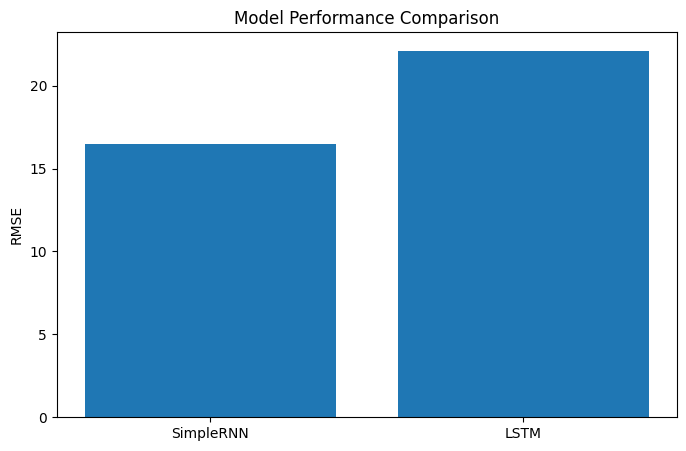

In [27]:
# final model evaluation
final_results = pd.DataFrame({
    "Model": ["SimpleRNN", "LSTM"],
    "RMSE": [rnn_rmse, lstm_rmse]
})

final_results

# visual comparison
plt.figure(figsize=(8,5))

plt.bar(
    final_results["Model"],
    final_results["RMSE"]
)

plt.title("Model Performance Comparison")
plt.ylabel("RMSE")

plt.show()

best_lstm_model.save("best_lstm_model.keras")

In [39]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from sklearn.preprocessing import MinMaxScaler

st.set_page_config(
    page_title="Tesla Stock Price Prediction",
    layout="wide"
)

st.title("Tesla Stock Price Prediction using LSTM")

# load dataset
data = pd.read_csv("TSLA.csv")

st.subheader("Dataset Preview")
st.dataframe(data.head())

st.subheader("Dataset Shape")
st.write(data.shape)

data["Date"] = pd.to_datetime(data["Date"])

# closing price trend
st.subheader("Tesla Closing Price Trend")

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    data["Date"],
    data["Close"]
)

ax.set_xlabel("Date")
ax.set_ylabel("Closing Price")
ax.set_title("Tesla Closing Price Over Time")

st.pyplot(fig)

# load trained model
model = load_model("best_lstm_model.keras")

# data scaling
close_data = data[["Close"]]

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(
    close_data
)

last_window = scaled_data[-60:]

last_window = last_window.reshape(
    1,
    60,
    1
)

# forecast function
def forecast_future_days(
    model,
    start_window,
    days_ahead
):

    predictions = []

    current_window = start_window.copy()

    for _ in range(days_ahead):

        next_value = model.predict(
            current_window,
            verbose=0
        )[0][0]

        predictions.append(next_value)

        next_value = np.array(
            next_value
        ).reshape(1, 1, 1)

        current_window = np.concatenate(
            [current_window[:, 1:, :], next_value],
            axis=1
        )

    return np.array(predictions)

# predictions
future_1 = forecast_future_days(
    model,
    last_window,
    1
)

future_5 = forecast_future_days(
    model,
    last_window,
    5
)

future_10 = forecast_future_days(
    model,
    last_window,
    10
)

future_1_actual = scaler.inverse_transform(
    future_1.reshape(-1, 1)
)

future_5_actual = scaler.inverse_transform(
    future_5.reshape(-1, 1)
)

future_10_actual = scaler.inverse_transform(
    future_10.reshape(-1, 1)
)

# 1-day prediction
st.subheader("Next Day Prediction")

st.metric(
    label="Predicted Closing Price",
    value=f"${future_1_actual[0][0]:.2f}"
)

# 5-day prediction
st.subheader("5-Day Forecast")

prediction_5 = pd.DataFrame({
    "Day": range(1, 6),
    "Predicted Price": future_5_actual.flatten()
})

st.dataframe(prediction_5)

# 10-day prediction
st.subheader("10-Day Forecast")

prediction_10 = pd.DataFrame({
    "Day": range(1, 11),
    "Predicted Price": future_10_actual.flatten()
})

st.dataframe(prediction_10)

# forecast visualization
st.subheader("10-Day Forecast Visualization")

fig2, ax2 = plt.subplots(figsize=(10, 5))

ax2.plot(
    prediction_10["Day"],
    prediction_10["Predicted Price"],
    marker="o"
)

ax2.set_xlabel("Future Day")
ax2.set_ylabel("Predicted Price")
ax2.set_title("Tesla Predicted Prices for Next 10 Days")

st.pyplot(fig2)

Overwriting app.py


In [40]:
# installing streamlit in colab
!pip install streamlit -q

# installing localTunnel
!npm install localtunnel

⠙⠹⠸⠼⠴⠦
up to date, audited 23 packages in 735ms
⠦
⠦3 packages are looking for funding
⠦  run `npm fund` for details
⠦
2 high severity vulnerabilities

To address all issues (including breaking changes), run:
  npm audit fix --force

Run `npm audit` for details.
⠦

In [41]:
# running streamlit
!streamlit run app.py &>/content/logs.txt &

In [ ]:
#create tunnel
!npx localtunnel --port 8501

⠙your url is: https://shy-ends-think.loca.lt


In [43]:
!tail -100 /content/logs.txt



2026-06-11 19:23:51.550 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.81.255.87:8501

2026-06-11 19:24:35.471823: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
  Stopping...
